In [8]:
from json import load
from typing import TypedDict, List
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
load_dotenv(override=True)

True

In [ ]:
class State(TypedDict):
    messages: list[HumanMessage]

In [27]:
llm = ChatOpenAI(model = "gpt-4o-mini")

In [28]:
def node(state: State) -> State:
    response = llm.invoke(state["messages"])
    print(f"AI: {response.content}")
    return state

In [29]:
graph = StateGraph(State)
graph.add_node("Node", node)
graph.add_edge(START, "Node")
graph.add_edge("Node", END)
agent = graph.compile()

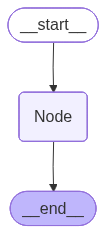

In [32]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [31]:
user_input = input("Enter: ")
agent.invoke({"messages": [HumanMessage(content=user_input)]})

AI: Hello! How can I assist you today?


{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})]}